
# Retail Sales Analysis: Customer Behavior, Product Performance, and Revenue Drivers

**Author:** Ghislain Niyongabo  
**Project Type:** End-to-end data analysis case study  
**Dataset:** Retail Sales and Customer Demographics Dataset

---

## 1. Business Case Outline

### Background
A retail business wants to understand which customers drive revenue, which product categories perform best, and how sales vary over time. The company also wants evidence-based recommendations for marketing, inventory, and sales planning.

### Business Problem
Management does not yet have a clear view of:
- who their most valuable customer groups are,
- which product categories are most attractive,
- how customer behavior changes across time and seasons,
- and what factors most strongly influence transaction value.

### Goal
Use transactional and customer demographic data to answer the most important commercial questions and convert the analysis into practical business recommendations.

### Main Analytical Questions
This project explicitly answers these seven questions:

1. **How does customer age and gender influence purchasing behavior?**
2. **Are there discernible patterns in sales across different time periods?**
3. **Which product categories hold the highest appeal among customers?**
4. **What are the relationships between age, spending, and product preferences?**
5. **How do customers adapt their shopping habits during seasonal trends?**
6. **Are there distinct purchasing behaviors based on the number of items bought per transaction?**
7. **What insights can be gleaned from the distribution of product prices within each category?**

### Success Criteria
A strong analysis should:
- quantify revenue and purchasing patterns,
- identify high-performing segments and categories,
- explain business meaning clearly,
- and provide actionable recommendations.

---

## 2. Imports and Data Loading


In [2]:
from google.colab import files
uploaded=files.upload()
print(uploaded)

Saving retail_sales_dataset.csv to retail_sales_dataset (1).csv
{'retail_sales_dataset (1).csv': b'Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount\r\n1,2023-11-24,CUST001,Male,34,Beauty,3,50,150\r\n2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000\r\n3,2023-01-13,CUST003,Male,50,Electronics,1,30,30\r\n4,2023-05-21,CUST004,Male,37,Clothing,1,500,500\r\n5,2023-05-06,CUST005,Male,30,Beauty,2,50,100\r\n6,2023-04-25,CUST006,Female,45,Beauty,1,30,30\r\n7,2023-03-13,CUST007,Male,46,Clothing,2,25,50\r\n8,2023-02-22,CUST008,Male,30,Electronics,4,25,100\r\n9,2023-12-13,CUST009,Male,63,Electronics,2,300,600\r\n10,2023-10-07,CUST010,Female,52,Clothing,4,50,200\r\n11,2023-02-14,CUST011,Male,23,Clothing,2,50,100\r\n12,2023-10-30,CUST012,Male,35,Beauty,3,25,75\r\n13,2023-08-05,CUST013,Male,22,Electronics,3,500,1500\r\n14,2023-01-17,CUST014,Male,64,Clothing,4,30,120\r\n15,2023-01-16,CUST015,Female,42,Electronics,4,500,2000\r\n16,2023-02-17,CUST016,Male

In [3]:

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Display options
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# Load data
df = pd.read_csv("retail_sales_dataset.csv")
df.head()


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


## 3. Data Understanding

In [4]:

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nSummary statistics:")
display(df.describe(include="all"))


Shape: (1000, 9)

Columns:
['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age', 'Product Category', 'Quantity', 'Price per Unit', 'Total Amount']

Data types:
Transaction ID       int64
Date                object
Customer ID         object
Gender              object
Age                  int64
Product Category    object
Quantity             int64
Price per Unit       int64
Total Amount         int64
dtype: object

Summary statistics:


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
count,"1,000.00",1000,1000,1000,"1,000.00",1000,"1,000.00","1,000.00","1,000.00"
unique,NaN,345,1000,2,NaN,3,NaN,NaN,NaN
top,NaN,2023-05-16,CUST1000,Female,NaN,Clothing,NaN,NaN,NaN
freq,NaN,11,1,510,NaN,351,NaN,NaN,NaN
mean,500.50,NaN,NaN,NaN,41.39,NaN,2.51,179.89,456.00
std,288.82,NaN,NaN,NaN,13.68,NaN,1.13,189.68,560.00
min,1.00,NaN,NaN,NaN,18.00,NaN,1.00,25.00,25.00
25%,250.75,NaN,NaN,NaN,29.00,NaN,1.00,30.00,60.00
50%,500.50,NaN,NaN,NaN,42.00,NaN,3.00,50.00,135.00
75%,750.25,NaN,NaN,NaN,53.00,NaN,4.00,300.00,900.00


## 4. Data Quality Checks and Cleaning

In [5]:

# Standardize column names for easier work
df.columns = (
    df.columns.str.strip()
              .str.lower()
              .str.replace(" ", "_")
)

# Convert date
df["date"] = pd.to_datetime(df["date"])

# Check missing values and duplicates
missing_values = df.isna().sum()
duplicate_rows = df.duplicated().sum()

print("Missing values by column:")
display(missing_values)

print(f"Duplicate rows: {duplicate_rows}")


Missing values by column:


,0
transaction_id,0
date,0
customer_id,0
gender,0
age,0
product_category,0
quantity,0
price_per_unit,0
total_amount,0


Duplicate rows: 0



### Cleaning Notes
- The dataset contains **no missing values**.
- The dataset contains **no duplicate rows**.
- The `date` column was converted to a datetime format for time-based analysis.

This means the data is already in good condition and can move directly into feature engineering and analysis.


## 5. Feature Engineering

In [6]:

# Time features
df["year"] = df["date"].dt.year
df["month_num"] = df["date"].dt.month
df["month"] = df["date"].dt.month_name().str[:3]
df["quarter"] = "Q" + df["date"].dt.quarter.astype(str)

# Age segments
df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 24, 34, 44, 54, 100],
    labels=["18-24", "25-34", "35-44", "45-54", "55+"],
    include_lowest=True
)

# Order-level KPI
df["avg_price_paid_per_item"] = df["total_amount"] / df["quantity"]

df.head()


,transaction_id,date,customer_id,gender,age,product_category,quantity,price_per_unit,total_amount,year,month_num,month,quarter,age_group,avg_price_paid_per_item
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,2023,11,Nov,Q4,25-34,50.00
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,2023,2,Feb,Q1,25-34,500.00
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,2023,1,Jan,Q1,45-54,30.00
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,2023,5,May,Q2,35-44,500.00
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,2023,5,May,Q2,25-34,50.00


## 6. Executive KPI Snapshot

In [7]:

total_revenue = df["total_amount"].sum()
avg_order_value = df["total_amount"].mean()
total_transactions = len(df)
unique_customers = df["customer_id"].nunique()
avg_quantity = df["quantity"].mean()
avg_unit_price = df["price_per_unit"].mean()

kpi = pd.DataFrame({
    "Metric": [
        "Total Revenue",
        "Average Order Value",
        "Transactions",
        "Unique Customers",
        "Average Quantity per Transaction",
        "Average Unit Price"
    ],
    "Value": [
        total_revenue,
        avg_order_value,
        total_transactions,
        unique_customers,
        avg_quantity,
        avg_unit_price
    ]
})

display(kpi)


,Metric,Value
0,Total Revenue,"456,000.00"
1,Average Order Value,456.00
2,Transactions,"1,000.00"
3,Unique Customers,"1,000.00"
4,Average Quantity per Transaction,2.51
5,Average Unit Price,179.89



### KPI Interpretation
- The dataset contains **1,000 transactions** and **1,000 unique customers**, which suggests one transaction per customer in this sample.
- Total revenue is **456,000**.
- Average order value is **456.00**, giving a clear benchmark for what a typical transaction looks like.
- Average quantity per transaction helps us understand whether value is driven by basket size or by more expensive items.



# 7. Business Question Analysis
Each section below answers one of the business questions explicitly and includes an interpretation.


## Question 1. How does customer age and gender influence purchasing behavior?

mean           sum         count     
gender    Female   Male Female   Male Female Male
age_group                                        
18-24     498.89 502.99  35920  38730     72   77
25-34     508.33 447.92  51850  45240    102  101
35-44     472.90 461.79  52965  43870    112   95
45-54     407.17 458.27  46825  50410    115  110
55+       415.41 419.72  45280  44910    109  107

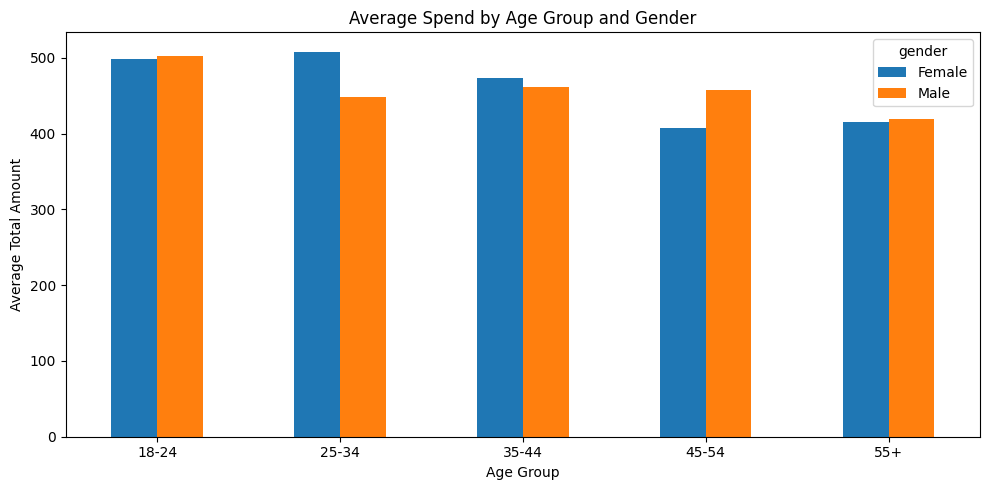

In [8]:

age_gender_summary = df.pivot_table(
    index="age_group",
    columns="gender",
    values="total_amount",
    aggfunc=["mean", "sum", "count"]
)

display(age_gender_summary)

avg_spend_by_age_gender = df.pivot_table(
    index="age_group",
    columns="gender",
    values="total_amount",
    aggfunc="mean"
)

avg_spend_by_age_gender.plot(kind="bar", figsize=(10, 5))
plt.title("Average Spend by Age Group and Gender")
plt.xlabel("Age Group")
plt.ylabel("Average Total Amount")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()



### Interpretation
The analysis shows that purchasing behavior differs by both **age** and **gender**:

- In the **18–24** segment, both genders spend at a relatively high level, with males slightly ahead on average.
- In the **25–34** segment, **female customers have the highest average spend** among the strongest segments.
- In the **35–44** segment, **female customers also show strong spending**, especially compared with males in the same band.
- In the **45–54** segment, males spend more on average than females.
- In the **55+** segment, average spending is more balanced, though still not among the highest overall.

**Business meaning:** the retail business should avoid treating all customers the same.  
The strongest spend patterns appear in **young-to-mid adult groups**, and the most valuable segment can change depending on gender. This supports more targeted promotions and messaging by demographic segment.


## Question 2. Are there discernible patterns in sales across different time periods?

,month_num,month,revenue,orders,avg_order_value
0,1,Jan,36980,78,474.10
1,2,Feb,44060,85,518.35
2,3,Mar,28990,73,397.12
3,4,Apr,33870,86,393.84
4,5,May,53150,105,506.19
5,6,Jun,36715,77,476.82
6,7,Jul,35465,72,492.57
7,8,Aug,36960,94,393.19
8,9,Sep,23620,65,363.38
9,10,Oct,46580,96,485.21


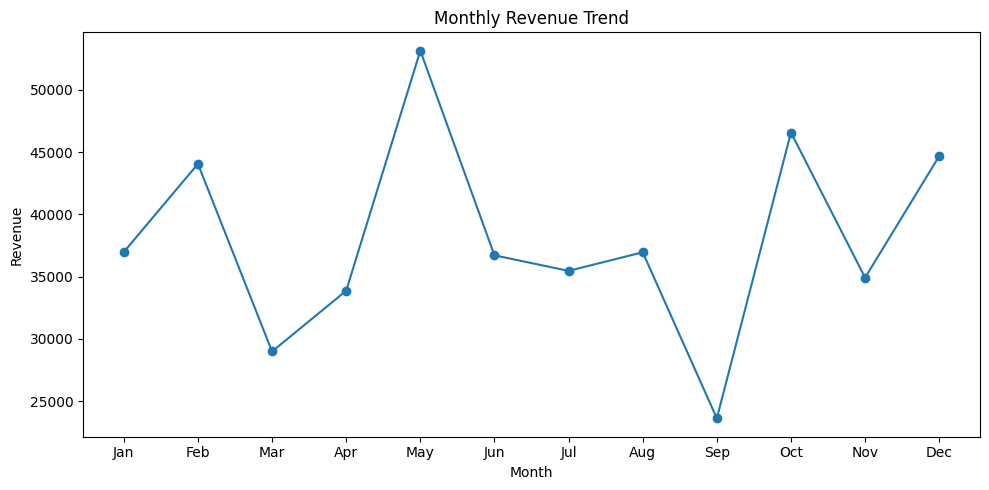

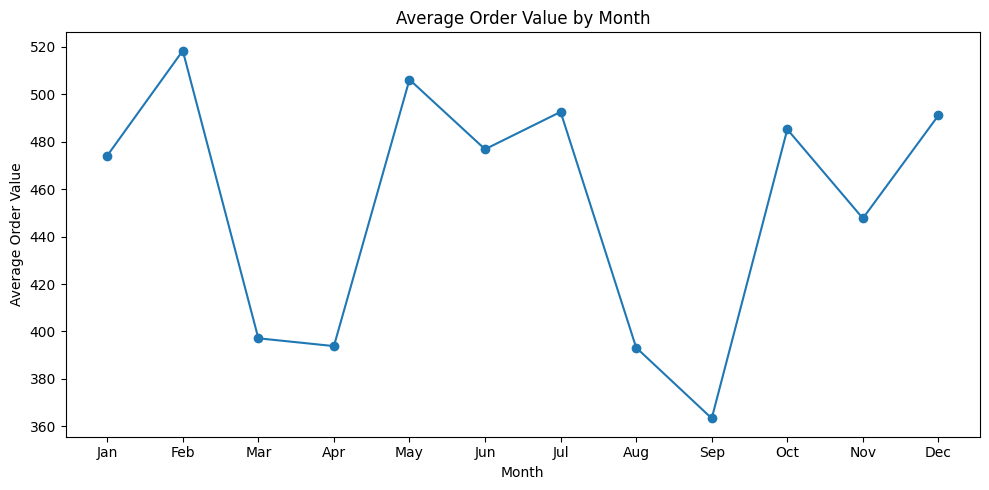

In [9]:

monthly_summary = df.groupby(["month_num", "month"]).agg(
    revenue=("total_amount", "sum"),
    orders=("transaction_id", "count"),
    avg_order_value=("total_amount", "mean")
).reset_index().sort_values("month_num")

display(monthly_summary)

plt.figure(figsize=(10, 5))
plt.plot(monthly_summary["month"], monthly_summary["revenue"], marker="o")
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(monthly_summary["month"], monthly_summary["avg_order_value"], marker="o")
plt.title("Average Order Value by Month")
plt.xlabel("Month")
plt.ylabel("Average Order Value")
plt.tight_layout()
plt.show()



### Interpretation
Yes, there are clear time-based patterns:

- **May** is the strongest revenue month in the dataset.
- **October**, **February**, and **December** also perform well.
- **September** is the weakest month by revenue.
- Average order value is lower in some months, showing that time patterns are not only about order count but also about **basket value**.

**Business meaning:** sales are not evenly distributed throughout the year.  
The business should plan marketing, staffing, and inventory around stronger periods such as **May, October, and December**, while using promotions or category bundling to support weaker periods like **September**.


## Question 3. Which product categories hold the highest appeal among customers?

,revenue,orders,quantity_sold,avg_unit_price
product_category,,,,
Electronics,156905,342,849,181.90
Clothing,155580,351,894,174.29
Beauty,143515,307,771,184.06


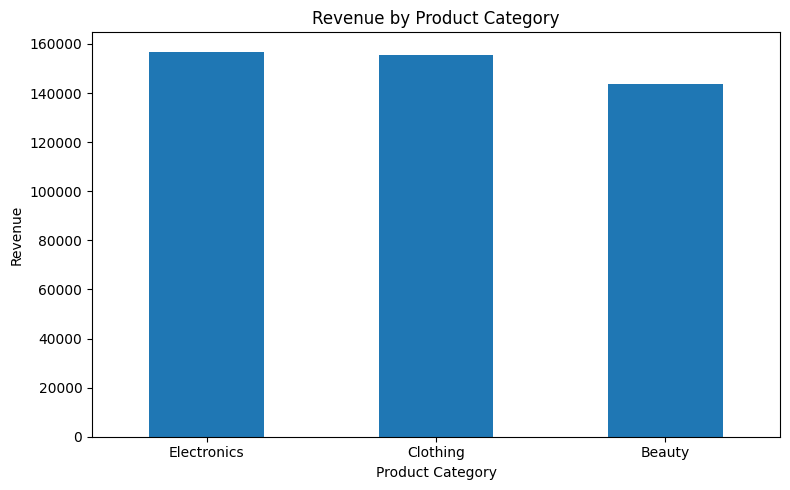

In [10]:

category_summary = df.groupby("product_category").agg(
    revenue=("total_amount", "sum"),
    orders=("transaction_id", "count"),
    quantity_sold=("quantity", "sum"),
    avg_unit_price=("price_per_unit", "mean")
).sort_values("revenue", ascending=False)

display(category_summary)

category_summary["revenue"].plot(kind="bar", figsize=(8, 5))
plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Revenue")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()



### Interpretation
The most appealing category by **revenue** is **Electronics**, followed very closely by **Clothing**, while **Beauty** ranks third.

This tells us that:
- **Electronics** delivers the highest commercial impact overall.
- **Clothing** is also very strong and slightly leads on quantity sold.
- **Beauty** remains important but generates less revenue than the other two categories in this sample.

**Business meaning:** the company should protect and grow its top two revenue engines, especially Electronics and Clothing.  
That could mean stronger stock availability, tailored campaigns, and upsell strategies in those categories.


## Question 4. What are the relationships between age, spending, and product preferences?

product_category,Beauty,Clothing,Electronics
age_group,,,
18-24,545.38,492.44,462.45
25-34,419.71,570.41,434.03
35-44,577.45,391.46,473.51
45-54,492.47,399.26,406.92
55+,333.39,391.38,516.35


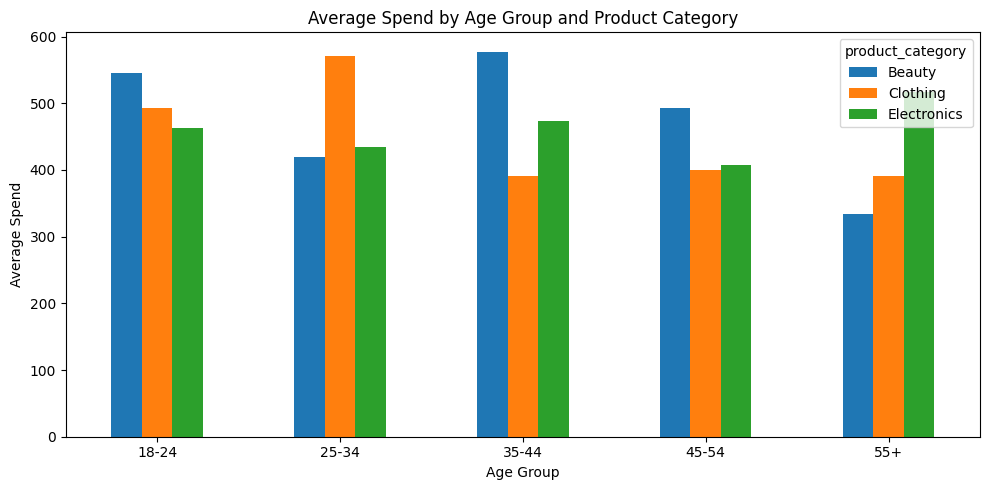

In [11]:

age_category_spend = df.pivot_table(
    index="age_group",
    columns="product_category",
    values="total_amount",
    aggfunc="mean"
)

display(age_category_spend)

age_category_spend.plot(kind="bar", figsize=(10, 5))
plt.title("Average Spend by Age Group and Product Category")
plt.xlabel("Age Group")
plt.ylabel("Average Spend")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()



### Interpretation
Age clearly interacts with product preference:

- Customers aged **18–24** spend the most on **Beauty**.
- Customers aged **25–34** spend the most on **Clothing**.
- Customers aged **35–44** again show the strongest average spend in **Beauty**.
- Customers aged **55+** spend the most on **Electronics**.

**Business meaning:** product preference is not the same across age groups.  
This supports age-based merchandising and promotion. For example:
- promote **Beauty** more strongly to younger and mid-career adults,
- push **Clothing** campaigns to 25–34 customers,
- and position **Electronics** prominently for older segments.


## Question 5. How do customers adapt their shopping habits during seasonal trends?

product_category,Beauty,Clothing,Electronics
month_num,,,
1,13930,13125,9925
2,14035,14560,15465
3,10545,15065,3380
4,11905,13940,8025
5,12450,17455,23245
6,10995,10170,15550
7,16090,8250,11125
8,9790,12455,14715
9,6320,9975,7325


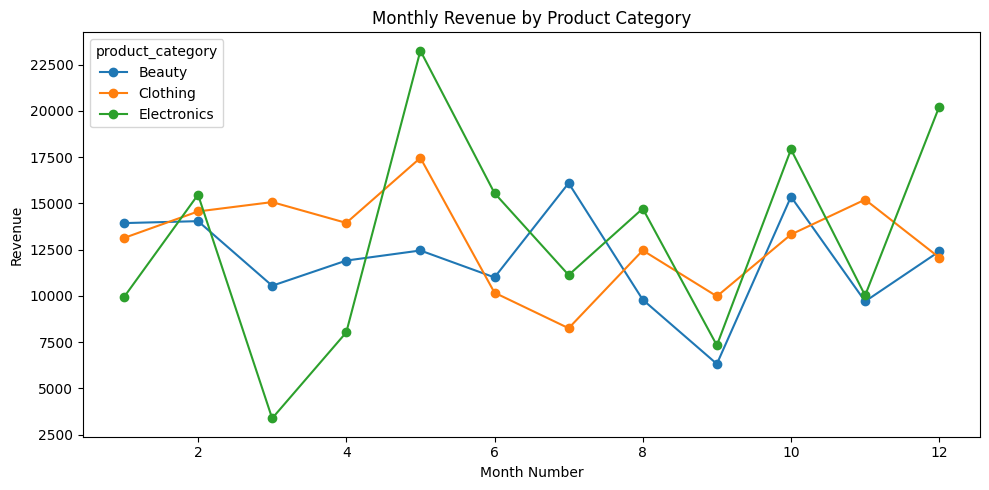

In [12]:

seasonal_category = df.pivot_table(
    index="month_num",
    columns="product_category",
    values="total_amount",
    aggfunc="sum"
).sort_index()

display(seasonal_category)

seasonal_category.plot(figsize=(10, 5), marker="o")
plt.title("Monthly Revenue by Product Category")
plt.xlabel("Month Number")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()



### Interpretation
Customer shopping habits do shift over time:

- **Electronics** peaks strongly in **May**, **October**, and **December**.
- **Clothing** performs especially well in **March**, **May**, and **November**.
- **Beauty** is comparatively stronger in **July** and **October**.

This means seasonal behavior is not just about total sales rising or falling.  
Customers also **change what they buy** depending on the period.

**Business meaning:** seasonal planning should happen at the **category level**, not only at the total business level.  
Marketing calendars, product launches, and stock allocation should be timed differently for Electronics, Clothing, and Beauty.


## Question 6. Are there distinct purchasing behaviors based on the number of items bought per transaction?

,orders,revenue,avg_order_value
quantity,,,
1,253,44805,177.09
2,243,81050,333.54
3,241,144285,598.69
4,263,185860,706.69


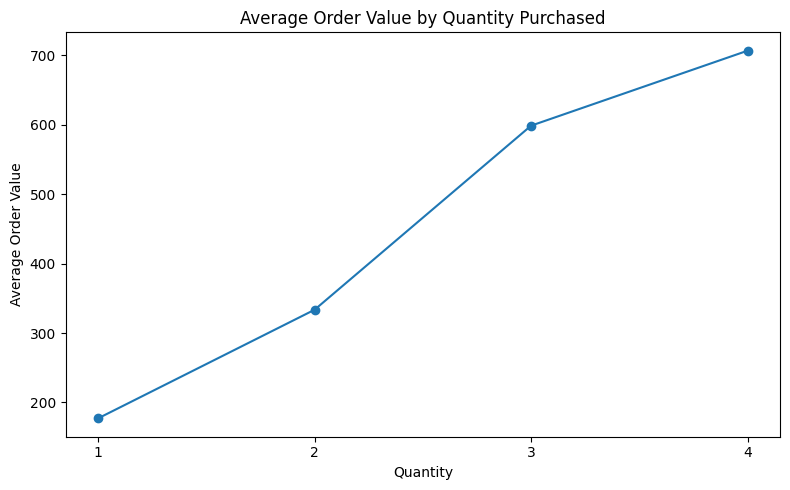

In [13]:

quantity_summary = df.groupby("quantity").agg(
    orders=("transaction_id", "count"),
    revenue=("total_amount", "sum"),
    avg_order_value=("total_amount", "mean")
).sort_index()

display(quantity_summary)

plt.figure(figsize=(8, 5))
plt.plot(quantity_summary.index, quantity_summary["avg_order_value"], marker="o")
plt.title("Average Order Value by Quantity Purchased")
plt.xlabel("Quantity")
plt.ylabel("Average Order Value")
plt.xticks(quantity_summary.index)
plt.tight_layout()
plt.show()



### Interpretation
Yes, purchasing behavior changes clearly with basket size:

- Transactions with **1 item** have the lowest average order value.
- As quantity increases from **1 to 4 items**, average order value rises strongly.
- Transactions with **4 items** generate the highest revenue and the highest average order value.

**Business meaning:** larger baskets are much more valuable.  
This creates a strong case for:
- bundle offers,
- “buy more” discounts,
- cross-sell recommendations,
- and checkout upselling to increase item count per order.


## Question 7. What insights can be gleaned from the distribution of product prices within each category?

,count,mean,std,min,25%,50%,75%,max
product_category,,,,,,,,
Beauty,307.00,184.06,194.93,25.00,30.00,50.00,300.00,500.00
Clothing,351.00,174.29,186.02,25.00,30.00,50.00,300.00,500.00
Electronics,342.00,181.90,189.05,25.00,30.00,50.00,300.00,500.00


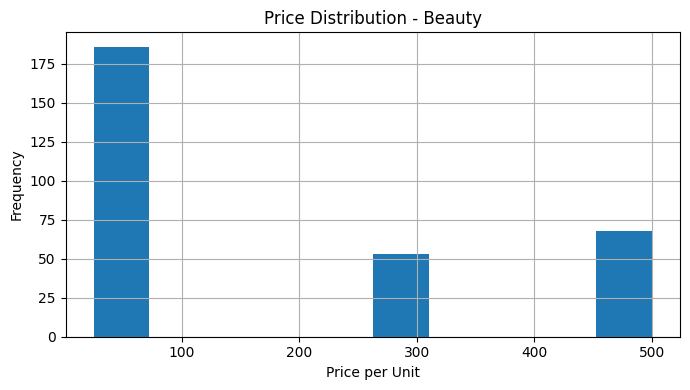

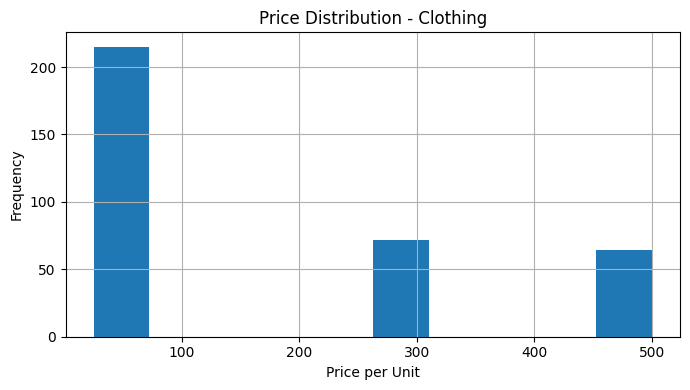

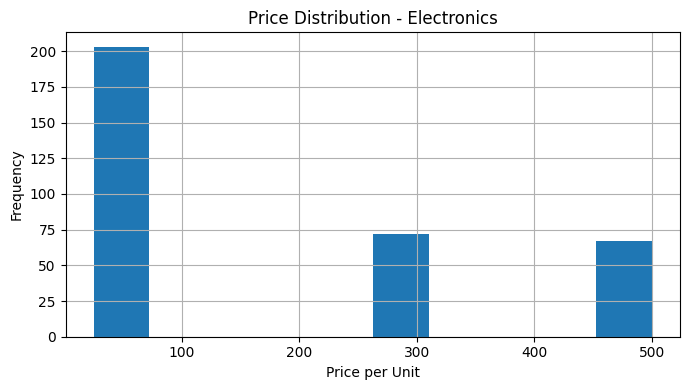

In [14]:

price_distribution = df.groupby("product_category")["price_per_unit"].describe()
display(price_distribution)

for category in df["product_category"].unique():
    plt.figure(figsize=(7, 4))
    df.loc[df["product_category"] == category, "price_per_unit"].hist(bins=10)
    plt.title(f"Price Distribution - {category}")
    plt.xlabel("Price per Unit")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()



### Interpretation
Price patterns are surprisingly similar across categories:

- The average unit price is fairly close across **Beauty**, **Clothing**, and **Electronics**.
- All categories include a wide range of prices, from low-cost items to premium-priced products.
- The standard deviations are also high, indicating broad price variety within each category.

**Business meaning:** each category appears to serve multiple price tiers rather than one fixed customer budget.  
That is useful because it allows the retailer to:
- attract both budget-conscious and premium customers,
- segment promotions by price tier,
- and design product mix strategies inside each category.


## 8. Relationship Analysis: Which variables drive transaction value?

,age,quantity,price_per_unit,total_amount,avg_price_paid_per_item
age,1.00,-0.02,-0.04,-0.06,-0.04
quantity,-0.02,1.00,0.02,0.37,0.02
price_per_unit,-0.04,0.02,1.00,0.85,1.00
total_amount,-0.06,0.37,0.85,1.00,0.85
avg_price_paid_per_item,-0.04,0.02,1.00,0.85,1.00


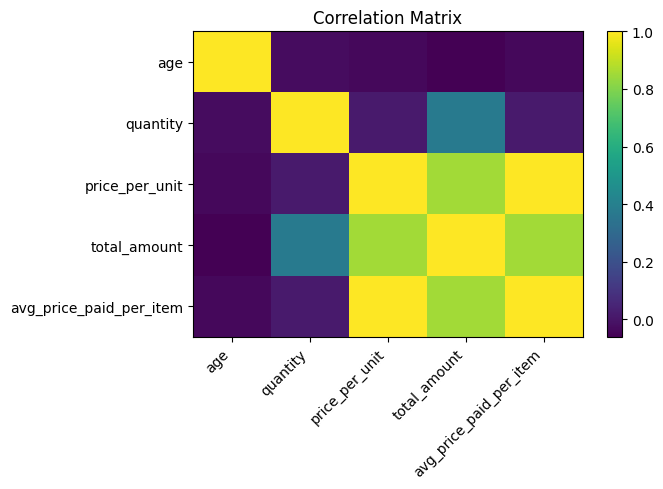

In [15]:

numeric_cols = ["age", "quantity", "price_per_unit", "total_amount", "avg_price_paid_per_item"]
corr = df[numeric_cols].corr()

display(corr)

plt.figure(figsize=(7, 5))
plt.imshow(corr, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.index)), corr.index)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()



### Interpretation
The strongest relationship with transaction value is expectedly linked to:
- **quantity**, because buying more items naturally increases total amount,
- and **price per unit**, because more expensive products drive larger order values.

Age is much less directly correlated with transaction value than quantity or price, which suggests that **customer demographics matter more for segmentation and targeting** than for directly predicting the exact value of a transaction.


## 9. Predictive Modeling: Estimating Transaction Value

In [16]:

X = df[["gender", "age", "product_category", "quantity", "price_per_unit"]]
y = df["total_amount"]

categorical_features = ["gender", "product_category"]
numeric_features = ["age", "quantity", "price_per_unit"]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

model.fit(X_train, y_train)
predictions = model.predict(X_test)

mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predictions)

metrics = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R²"],
    "Value": [mae, rmse, r2]
})

display(metrics)


,Metric,Value
0,MAE,173.21
1,RMSE,204.66
2,R²,0.86


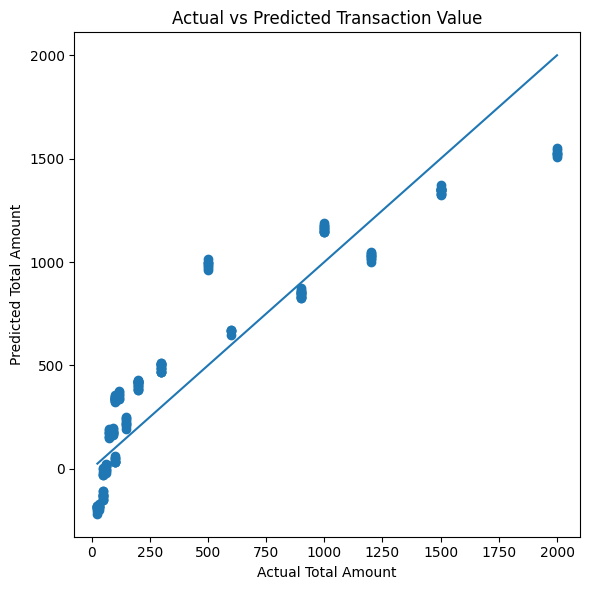

In [17]:

plt.figure(figsize=(6, 6))
plt.scatter(y_test, predictions)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)
plt.title("Actual vs Predicted Transaction Value")
plt.xlabel("Actual Total Amount")
plt.ylabel("Predicted Total Amount")
plt.tight_layout()
plt.show()



### Model Interpretation
The regression model performs well for a simple baseline model:

- **R² is approximately 0.86**, which means the model explains a large share of variation in transaction value.
- This makes sense because **quantity** and **price per unit** are strong drivers of total amount.
- Demographic variables like **age** and **gender** add business context, though they are less powerful than basket and product variables for direct prediction.

**Business meaning:** the retailer can use a model like this as a first step for:
- estimating expected transaction value,
- flagging unusually low or high baskets,
- and improving sales forecasting.


## 10. Final Business Recommendations


Based on the analysis, the retail business should consider the following actions:

### 1. Segment marketing by age and gender
Different customer groups behave differently. Campaigns should be tailored, especially for high-value adult segments.

### 2. Prioritize Electronics and Clothing
These are the strongest categories by commercial value. They deserve focused inventory planning and campaign investment.

### 3. Plan around strong and weak months
Revenue peaks in months such as **May**, **October**, and **December**, while weaker months such as **September** may need targeted promotional support.

### 4. Increase basket size
Since larger item counts drive much higher order values, the business should use bundles, cross-sell offers, and quantity discounts.

### 5. Use category-level seasonality
Customers change product preferences by month. Inventory and promotions should be planned separately for each category.

### 6. Maintain a balanced price architecture
Each category serves multiple price tiers, so retailers should preserve a mix of entry-level and premium products.


## 11. Conclusion


This project answers the original business questions with both **analysis and interpretation**.

It demonstrates a complete professional workflow:
- business understanding,
- data quality checks,
- feature engineering,
- exploratory data analysis,
- insight generation,
- and predictive modeling.

Most importantly, it translates data into **business action** rather than stopping at charts.

That is what makes a portfolio project look like real analyst work.
